# Train and Evaluate ALICE-Like Low-Light Enhancement Model

This notebook trains and evaluates an ALICE-like low-light enhancement model using the prepared dataset:

```text
data/processed/
├── train/
│   ├── rgb_low/
│   ├── mono_low/
│   └── gt/
└── test/
    ├── rgb_low/
    ├── mono_low/
    └── gt/
```


In [1]:
# 1. Imports

from pathlib import Path
import importlib.util
import random
import sys
import types

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


C:\Users\Uday Singh\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 2. Config

SEED = 42
BATCH_SIZE = 2
LEARNING_RATE = 1e-4
EPOCHS = 5
NUM_WORKERS = 0
USE_TELU = False
USE_AMP = True
CHANNELS = 32
L1_WEIGHT = 1.0
EDGE_WEIGHT = 0.2
NUM_RESULTS_TO_SAVE = 30
NUM_RESULTS_TO_DISPLAY = 3

DATA_ROOT = Path("data/processed")
TRAIN_ROOT = DATA_ROOT / "train"
TEST_ROOT = DATA_ROOT / "test"
CHECKPOINT_DIR = Path("checkpoints")
OUTPUT_DIR = Path("outputs")
BASE_MODEL_FILE = Path("experiments/pre_trained_model/ALICC.py")
PRETRAINED_WEIGHTS = Path("experiments/pre_trained_model/model_best.pth")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = USE_AMP and DEVICE.type == "cuda"


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for split_root in (TRAIN_ROOT, TEST_ROOT):
    for subdir_name in ("rgb_low", "mono_low", "gt"):
        subdir = split_root / subdir_name
        if not subdir.exists():
            raise FileNotFoundError(f"Missing required folder: {subdir}")

print(f"Device: {DEVICE}")
print(f"AMP enabled: {AMP_ENABLED}")
print(f"Use TELU: {USE_TELU}")
print(f"Pretrained weights found: {PRETRAINED_WEIGHTS.exists()}")
print(f"Results to save: {NUM_RESULTS_TO_SAVE}")
print(f"Results to display: {NUM_RESULTS_TO_DISPLAY}")


Device: cuda
AMP enabled: True
Use TELU: True
Pretrained weights found: True
Results to save: 30
Results to display: 3


In [3]:
# 3. Dataset Loader

VALID_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def index_image_files(folder: Path) -> dict[str, Path]:
    return {
        path.name: path
        for path in sorted(folder.iterdir())
        if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS
    }


def load_rgb_image(path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Could not load RGB image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def load_mono_image(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Could not load grayscale image: {path}")
    return image


class ProcessedLowLightDataset(Dataset):
    def __init__(self, root_dir: Path):
        self.root_dir = Path(root_dir)
        self.rgb_low_dir = self.root_dir / "rgb_low"
        self.mono_low_dir = self.root_dir / "mono_low"
        self.gt_dir = self.root_dir / "gt"

        rgb_index = index_image_files(self.rgb_low_dir)
        mono_index = index_image_files(self.mono_low_dir)
        gt_index = index_image_files(self.gt_dir)

        rgb_names = set(rgb_index)
        mono_names = set(mono_index)
        gt_names = set(gt_index)

        if not rgb_names:
            raise RuntimeError(f"No samples found in {self.rgb_low_dir}")
        if rgb_names != mono_names or rgb_names != gt_names:
            raise ValueError("Filename mismatch detected across rgb_low, mono_low, and gt folders.")

        self.samples = [
            {
                "name": name,
                "rgb_low_path": rgb_index[name],
                "mono_low_path": mono_index[name],
                "gt_path": gt_index[name],
            }
            for name in sorted(rgb_names)
        ]

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> dict:
        sample = self.samples[index]
        rgb_low = load_rgb_image(sample["rgb_low_path"]).astype(np.float32) / 255.0
        mono_low = load_mono_image(sample["mono_low_path"]).astype(np.float32) / 255.0
        gt = load_rgb_image(sample["gt_path"]).astype(np.float32) / 255.0

        return {
            "name": sample["name"],
            "rgb_low": torch.from_numpy(rgb_low.transpose(2, 0, 1)).float().contiguous(),
            "mono_low": torch.from_numpy(mono_low[None, ...]).float().contiguous(),
            "gt": torch.from_numpy(gt.transpose(2, 0, 1)).float().contiguous(),
        }


train_dataset = ProcessedLowLightDataset(TRAIN_ROOT)
test_dataset = ProcessedLowLightDataset(TEST_ROOT)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 540
Test samples: 60


In [4]:
# 4. Model Loading / Modification


class TELU(nn.Module):
    def __init__(self, clamp_value: float = 20.0):
        super().__init__()
        self.clamp_value = clamp_value

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        exp_term = torch.exp(torch.clamp(x, min=-self.clamp_value, max=self.clamp_value))
        return x * torch.tanh(exp_term)


def replace_relu_with_telu(module: nn.Module) -> int:
    replaced = 0
    for child_name, child in module.named_children():
        if isinstance(child, (nn.ReLU, nn.LeakyReLU)):
            setattr(module, child_name, TELU())
            replaced += 1
        else:
            replaced += replace_relu_with_telu(child)
    return replaced


def ensure_optional_dependency_stubs() -> None:
    if "ptflops" not in sys.modules:
        ptflops_stub = types.ModuleType("ptflops")

        def _missing_ptflops(*_args, **_kwargs):
            raise ImportError("ptflops is not installed.")

        ptflops_stub.get_model_complexity_info = _missing_ptflops
        sys.modules["ptflops"] = ptflops_stub

    if "timm" not in sys.modules:
        timm_stub = types.ModuleType("timm")
        timm_models_stub = types.ModuleType("timm.models")
        timm_layers_stub = types.ModuleType("timm.models.layers")

        class DropPath(nn.Identity):
            pass

        timm_layers_stub.DropPath = DropPath
        timm_models_stub.layers = timm_layers_stub
        timm_stub.models = timm_models_stub
        sys.modules["timm"] = timm_stub
        sys.modules["timm.models"] = timm_models_stub
        sys.modules["timm.models.layers"] = timm_layers_stub


def load_base_model_class(model_file: Path):
    ensure_optional_dependency_stubs()
    module_name = "_train_eval_alicc"
    if module_name in sys.modules:
        module = sys.modules[module_name]
    else:
        if not model_file.exists():
            raise FileNotFoundError(f"Base model file not found: {model_file}")
        spec = importlib.util.spec_from_file_location(module_name, model_file)
        if spec is None or spec.loader is None:
            raise ImportError(f"Failed to load model definition from {model_file}")
        module = importlib.util.module_from_spec(spec)
        sys.modules[module_name] = module
        spec.loader.exec_module(module)
    return module.ALICC


def normalize_state_dict_keys(state_dict: dict) -> dict:
    normalized = {}
    for key, value in state_dict.items():
        normalized[key[7:] if key.startswith("module.") else key] = value
    return normalized


def load_pretrained_weights(model: nn.Module, checkpoint_path: Path, map_location: torch.device) -> None:
    checkpoint = torch.load(checkpoint_path, map_location=map_location)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    elif isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    state_dict = normalize_state_dict_keys(state_dict)
    model.load_state_dict(state_dict, strict=True)


def extract_restored_output(model_output):
    if isinstance(model_output, (tuple, list)):
        return model_output[0]
    return model_output


def build_model(use_telu: bool, device: torch.device):
    BaseALICC = load_base_model_class(BASE_MODEL_FILE)
    model = BaseALICC(Ch_img=3, Channels=CHANNELS, state="Train", REF=True, tests=False)
    replaced_count = replace_relu_with_telu(model) if use_telu else 0

    if PRETRAINED_WEIGHTS.exists():
        load_pretrained_weights(model, PRETRAINED_WEIGHTS, map_location=device)
        print(f"Loaded pretrained weights from {PRETRAINED_WEIGHTS}")
    else:
        print("Pretrained weights not found. Training will start from random initialization.")

    return model.to(device), replaced_count


model, replaced_count = build_model(USE_TELU, DEVICE)
print(f"Replaced activations with TELU: {replaced_count}")


Loaded pretrained weights from experiments\pre_trained_model\model_best.pth
Replaced activations with TELU: 15


In [5]:
# 5. Loss Functions


def rgb_to_luminance(image: torch.Tensor) -> torch.Tensor:
    if image.size(1) == 1:
        return image
    r = image[:, 0:1]
    g = image[:, 1:2]
    b = image[:, 2:3]
    return 0.299 * r + 0.587 * g + 0.114 * b


class SobelEdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        sobel_x = torch.tensor(
            [[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32
        ).view(1, 1, 3, 3)
        sobel_y = torch.tensor(
            [[-1.0, -2.0, -1.0], [0.0, 0.0, 0.0], [1.0, 2.0, 1.0]], dtype=torch.float32
        ).view(1, 1, 3, 3)
        self.register_buffer("sobel_x", sobel_x)
        self.register_buffer("sobel_y", sobel_y)

    def gradient_magnitude(self, image: torch.Tensor) -> torch.Tensor:
        luminance = rgb_to_luminance(image)
        grad_x = F.conv2d(luminance, self.sobel_x, padding=1)
        grad_y = F.conv2d(luminance, self.sobel_y, padding=1)
        return torch.sqrt(grad_x.pow(2) + grad_y.pow(2) + 1e-6)

    def forward(self, prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return F.l1_loss(self.gradient_magnitude(prediction), self.gradient_magnitude(target))


class TotalEnhancementLoss(nn.Module):
    def __init__(self, l1_weight: float = 1.0, edge_weight: float = 0.2):
        super().__init__()
        self.l1_weight = l1_weight
        self.edge_weight = edge_weight
        self.edge_loss = SobelEdgeLoss()

    def forward(self, prediction: torch.Tensor, target: torch.Tensor):
        l1_value = F.l1_loss(prediction, target)
        edge_value = self.edge_loss(prediction, target)
        total = self.l1_weight * l1_value + self.edge_weight * edge_value
        return total, {"total": total, "l1": l1_value, "edge": edge_value}


def make_gaussian_window(window_size: int, sigma: float, channels: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    coords = torch.arange(window_size, device=device, dtype=dtype) - window_size // 2
    gaussian = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    gaussian = gaussian / gaussian.sum()
    window_2d = gaussian[:, None] @ gaussian[None, :]
    window_2d = window_2d / window_2d.sum()
    return window_2d.view(1, 1, window_size, window_size).repeat(channels, 1, 1, 1)


def psnr_torch(prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    prediction = prediction.clamp(0.0, 1.0)
    target = target.clamp(0.0, 1.0)
    mse = F.mse_loss(prediction, target, reduction="none").mean(dim=(1, 2, 3))
    return 20.0 * torch.log10(1.0 / torch.sqrt(mse.clamp_min(1e-8)))


def ssim_torch(prediction: torch.Tensor, target: torch.Tensor, window_size: int = 11, sigma: float = 1.5) -> torch.Tensor:
    prediction = prediction.clamp(0.0, 1.0)
    target = target.clamp(0.0, 1.0)
    channels = prediction.size(1)
    window = make_gaussian_window(window_size, sigma, channels, prediction.device, prediction.dtype)

    mu_pred = F.conv2d(prediction, window, padding=window_size // 2, groups=channels)
    mu_target = F.conv2d(target, window, padding=window_size // 2, groups=channels)
    mu_pred_sq = mu_pred.pow(2)
    mu_target_sq = mu_target.pow(2)
    mu_pred_target = mu_pred * mu_target

    sigma_pred_sq = F.conv2d(prediction * prediction, window, padding=window_size // 2, groups=channels) - mu_pred_sq
    sigma_target_sq = F.conv2d(target * target, window, padding=window_size // 2, groups=channels) - mu_target_sq
    sigma_pred_target = F.conv2d(prediction * target, window, padding=window_size // 2, groups=channels) - mu_pred_target

    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    numerator = (2 * mu_pred_target + c1) * (2 * sigma_pred_target + c2)
    denominator = (mu_pred_sq + mu_target_sq + c1) * (sigma_pred_sq + sigma_target_sq + c2)
    ssim_map = numerator / denominator.clamp_min(1e-8)
    return ssim_map.mean(dim=(1, 2, 3))


criterion = TotalEnhancementLoss(l1_weight=L1_WEIGHT, edge_weight=EDGE_WEIGHT).to(DEVICE)


In [6]:
# 6. Training Loop

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


def move_batch_to_device(batch: dict, device: torch.device):
    return (
        batch["rgb_low"].to(device, non_blocking=True),
        batch["mono_low"].to(device, non_blocking=True),
        batch["gt"].to(device, non_blocking=True),
    )


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer, criterion, scaler, device: torch.device):
    model.train()
    running_total = 0.0
    running_l1 = 0.0
    running_edge = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)
    for batch in progress_bar:
        rgb_low, mono_low, gt = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            raw_prediction = extract_restored_output(model(rgb_low, mono_low))
            total_loss, loss_dict = criterion(raw_prediction, gt)

        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_total += float(loss_dict["total"].detach().cpu().item())
        running_l1 += float(loss_dict["l1"].detach().cpu().item())
        running_edge += float(loss_dict["edge"].detach().cpu().item())

        progress_bar.set_postfix(
            total=f"{loss_dict['total'].detach().cpu().item():.4f}",
            l1=f"{loss_dict['l1'].detach().cpu().item():.4f}",
            edge=f"{loss_dict['edge'].detach().cpu().item():.4f}",
        )

    num_batches = max(len(loader), 1)
    return {
        "total": running_total / num_batches,
        "l1": running_l1 / num_batches,
        "edge": running_edge / num_batches,
    }


training_history = []
for epoch in range(1, EPOCHS + 1):
    epoch_losses = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
    training_history.append(epoch_losses)

    checkpoint_path = CHECKPOINT_DIR / f"model_epoch_{epoch}.pth"
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "config": {
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "epochs": EPOCHS,
                "device": str(DEVICE),
                "use_telu": USE_TELU,
            },
        },
        checkpoint_path,
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"total: {epoch_losses['total']:.4f} | "
        f"l1: {epoch_losses['l1']:.4f} | "
        f"edge: {epoch_losses['edge']:.4f} | "
        f"checkpoint: {checkpoint_path}"
    )


C:\Users\Uday Singh\AppData\Local\Temp\ipykernel_2656\3486043409.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
Training:   0%|          | 0/270 [00:00<?, ?it/s]C:\Users\Uday Singh\AppData\Local\Temp\ipykernel_2656\3486043409.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Epoch 01/5 | total: 0.0769 | l1: 0.0536 | edge: 0.1162 | checkpoint: checkpoints\model_epoch_1.pth


Epoch 02/5 | total: 0.0588 | l1: 0.0375 | edge: 0.1064 | checkpoint: checkpoints\model_epoch_2.pth


Epoch 03/5 | total: 0.0551 | l1: 0.0346 | edge: 0.1026 | checkpoint: checkpoints\model_epoch_3.pth


Epoch 04/5 | total: 0.0535 | l1: 0.0334 | edge: 0.1005 | checkpoint: checkpoints\model_epoch_4.pth


Epoch 05/5 | total: 0.0507 | l1: 0.0310 | edge: 0.0985 | checkpoint: checkpoints\model_epoch_5.pth


Loss curves saved to outputs\training_loss_curves.png


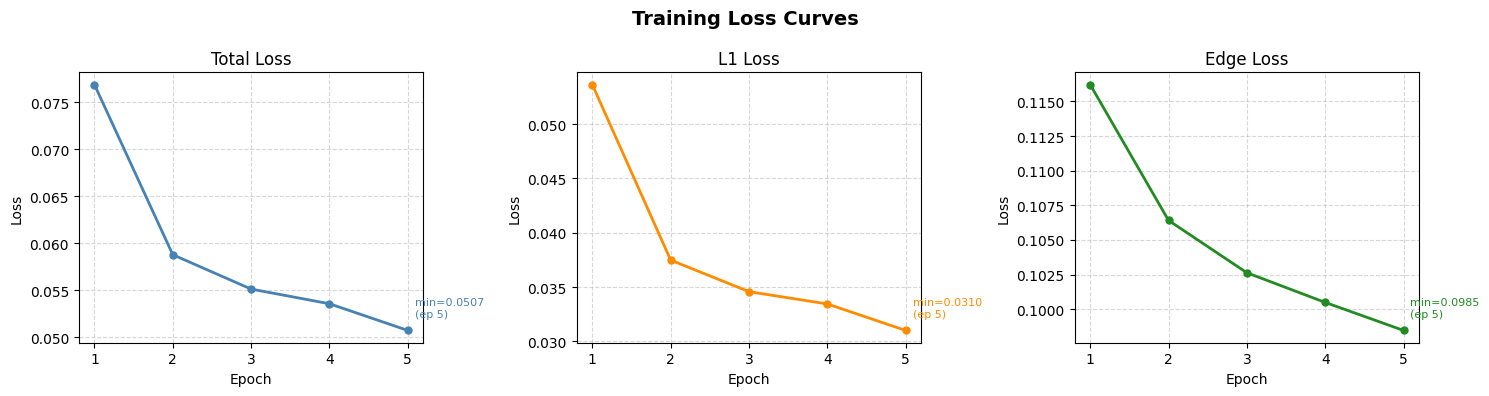

Loss history JSON saved to outputs\training_loss_curves.json


In [7]:
# 6b. Training Loss Curves

import json as _json

CURVES_DIR = OUTPUT_DIR  # reuse same output directory


def plot_and_save_loss_curves(
    history: list[dict],
    save_path: Path,
    show: bool = True,
) -> None:
    """Plot total / L1 / edge loss curves and save to disk."""
    if not history:
        print("No training history to plot.")
        return

    epochs_x = list(range(1, len(history) + 1))
    total_losses = [h["total"] for h in history]
    l1_losses    = [h["l1"]    for h in history]
    edge_losses  = [h["edge"]  for h in history]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Training Loss Curves", fontsize=14, fontweight="bold")

    for ax, values, label, color in zip(
        axes,
        [total_losses, l1_losses, edge_losses],
        ["Total Loss", "L1 Loss", "Edge Loss"],
        ["steelblue", "darkorange", "forestgreen"],
    ):
        ax.plot(epochs_x, values, marker="o", color=color, linewidth=2, markersize=5)
        ax.set_title(label)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_xticks(epochs_x)
        ax.grid(True, linestyle="--", alpha=0.5)
        # annotate min value
        min_idx = int(np.argmin(values))
        ax.annotate(
            f"min={values[min_idx]:.4f}\n(ep {epochs_x[min_idx]})",
            xy=(epochs_x[min_idx], values[min_idx]),
            xytext=(5, 10),
            textcoords="offset points",
            fontsize=8,
            color=color,
        )

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Loss curves saved to {save_path}")
    if show:
        plt.show()
    plt.close(fig)

    # also save the raw numbers as JSON for later analysis
    json_path = save_path.with_suffix(".json")
    with open(json_path, "w") as f:
        _json.dump({"epochs": epochs_x, "history": history}, f, indent=2)
    print(f"Loss history JSON saved to {json_path}")


loss_curve_path = CURVES_DIR / "training_loss_curves.png"
plot_and_save_loss_curves(training_history, loss_curve_path, show=True)


In [8]:
# 7. Evaluation


def evaluate_model(model: nn.Module, loader: DataLoader, device: torch.device, max_visual_samples: int = 30):
    model.eval()
    psnr_scores = []
    ssim_scores = []
    visual_samples = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Evaluating", leave=False)
        for batch in progress_bar:
            rgb_low, mono_low, gt = move_batch_to_device(batch, device)
            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                prediction = extract_restored_output(model(rgb_low, mono_low)).clamp(0.0, 1.0)

            psnr_scores.extend(psnr_torch(prediction, gt).detach().cpu().tolist())
            ssim_scores.extend(ssim_torch(prediction, gt).detach().cpu().tolist())

            names = batch["name"]
            for sample_index in range(prediction.size(0)):
                if len(visual_samples) < max_visual_samples:
                    visual_samples.append(
                        {
                            "name": names[sample_index] if isinstance(names, list) else f"sample_{len(visual_samples)+1}.png",
                            "rgb_low": rgb_low[sample_index].detach().cpu(),
                            "mono_low": mono_low[sample_index].detach().cpu(),
                            "output": prediction[sample_index].detach().cpu(),
                            "gt": gt[sample_index].detach().cpu(),
                        }
                    )

    avg_psnr = float(np.mean(psnr_scores)) if psnr_scores else float("nan")
    avg_ssim = float(np.mean(ssim_scores)) if ssim_scores else float("nan")
    return avg_psnr, avg_ssim, visual_samples


avg_psnr, avg_ssim, visual_samples = evaluate_model(model, test_loader, DEVICE, max_visual_samples=NUM_RESULTS_TO_SAVE)
print(f"Average PSNR on test set: {avg_psnr:.4f}")
print(f"Average SSIM on test set: {avg_ssim:.4f}")
print(f"Collected {len(visual_samples)} samples for saving to {OUTPUT_DIR}")


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]C:\Users\Uday Singh\AppData\Local\Temp\ipykernel_2656\1300704829.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                                                           

Average PSNR on test set: 27.9659
Average SSIM on test set: 0.7381
Collected 30 samples for saving to outputs


Re-evaluating for curves:   0%|          | 0/60 [00:00<?, ?it/s]C:\Users\Uday Singh\AppData\Local\Temp\ipykernel_2656\3632817635.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Eval metric curves saved to outputs\eval_metric_curves.png


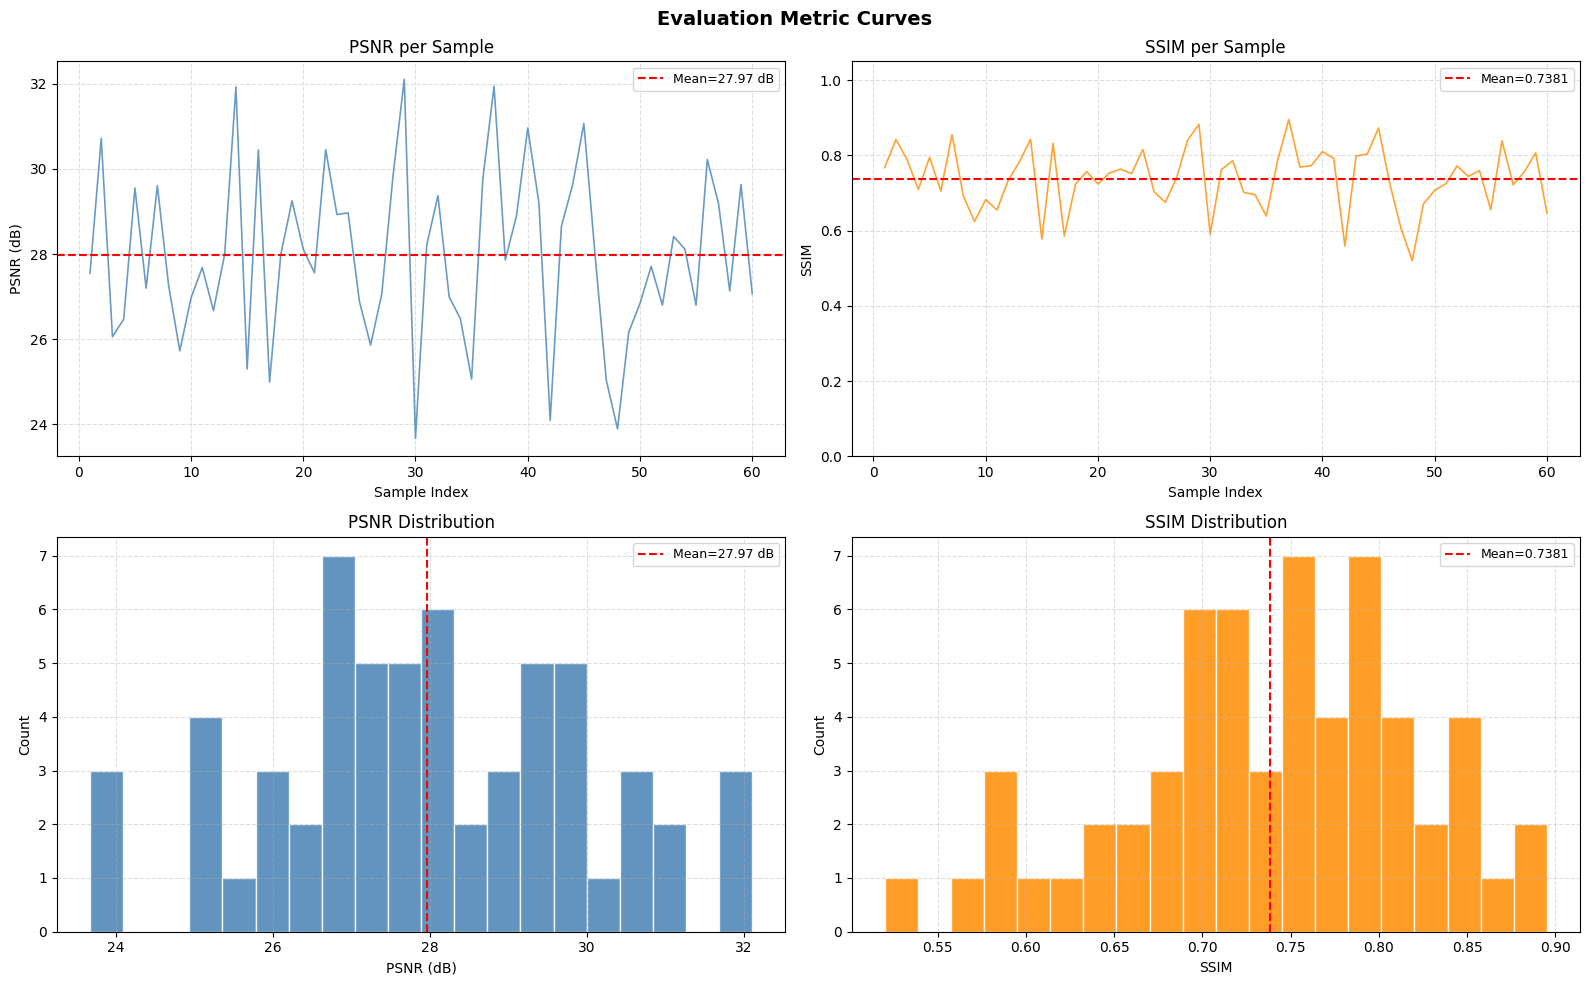

Per-sample metrics CSV saved to outputs\eval_metric_curves.csv

Summary  |  PSNR: 27.9659 dB  |  SSIM: 0.7381


In [9]:
# 7b. Evaluation Metric Curves


def evaluate_model_with_curves(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    max_visual_samples: int = 30,
):
    """Same as evaluate_model but returns per-sample metric lists too."""
    model.eval()
    psnr_per_sample: list[float] = []
    ssim_per_sample: list[float] = []
    sample_names:    list[str]   = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Re-evaluating for curves", leave=False)
        for batch in progress_bar:
            rgb_low, mono_low, gt = move_batch_to_device(batch, device)
            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                prediction = extract_restored_output(model(rgb_low, mono_low)).clamp(0.0, 1.0)

            batch_psnr = psnr_torch(prediction, gt).detach().cpu().tolist()
            batch_ssim = ssim_torch(prediction, gt).detach().cpu().tolist()
            names = batch["name"]

            for i in range(prediction.size(0)):
                psnr_per_sample.append(batch_psnr[i] if isinstance(batch_psnr, list) else batch_psnr)
                ssim_per_sample.append(batch_ssim[i] if isinstance(batch_ssim, list) else batch_ssim)
                sample_names.append(names[i] if isinstance(names, list) else f"sample_{len(sample_names)+1}")

    return psnr_per_sample, ssim_per_sample, sample_names


def plot_and_save_eval_curves(
    psnr_list: list[float],
    ssim_list: list[float],
    sample_names: list[str],
    save_path: Path,
    show: bool = True,
) -> None:
    """Plot per-sample PSNR & SSIM curves/histograms and save to disk."""
    if not psnr_list:
        print("No evaluation data to plot.")
        return

    indices = list(range(1, len(psnr_list) + 1))
    avg_psnr_val = float(np.mean(psnr_list))
    avg_ssim_val = float(np.mean(ssim_list))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Evaluation Metric Curves", fontsize=14, fontweight="bold")

    # --- PSNR per sample ---
    ax = axes[0, 0]
    ax.plot(indices, psnr_list, color="steelblue", linewidth=1.2, alpha=0.8)
    ax.axhline(avg_psnr_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean={avg_psnr_val:.2f} dB")
    ax.set_title("PSNR per Sample")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("PSNR (dB)")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

    # --- SSIM per sample ---
    ax = axes[0, 1]
    ax.plot(indices, ssim_list, color="darkorange", linewidth=1.2, alpha=0.8)
    ax.axhline(avg_ssim_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean={avg_ssim_val:.4f}")
    ax.set_title("SSIM per Sample")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("SSIM")
    ax.set_ylim(0.0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

    # --- PSNR histogram ---
    ax = axes[1, 0]
    ax.hist(psnr_list, bins=min(20, len(psnr_list)), color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(avg_psnr_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean={avg_psnr_val:.2f} dB")
    ax.set_title("PSNR Distribution")
    ax.set_xlabel("PSNR (dB)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

    # --- SSIM histogram ---
    ax = axes[1, 1]
    ax.hist(ssim_list, bins=min(20, len(ssim_list)), color="darkorange", edgecolor="white", alpha=0.85)
    ax.axvline(avg_ssim_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean={avg_ssim_val:.4f}")
    ax.set_title("SSIM Distribution")
    ax.set_xlabel("SSIM")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Eval metric curves saved to {save_path}")
    if show:
        plt.show()
    plt.close(fig)

    # also save per-sample CSV for further analysis
    csv_path = save_path.with_suffix(".csv")
    with open(csv_path, "w") as f:
        f.write("sample_name,psnr,ssim\n")
        for name, p, s in zip(sample_names, psnr_list, ssim_list):
            f.write(f"{name},{p:.6f},{s:.6f}\n")
    print(f"Per-sample metrics CSV saved to {csv_path}")


# run the per-sample evaluation pass
psnr_per_sample, ssim_per_sample, eval_sample_names = evaluate_model_with_curves(
    model, test_loader, DEVICE, max_visual_samples=NUM_RESULTS_TO_SAVE
)

eval_curve_path = CURVES_DIR / "eval_metric_curves.png"
plot_and_save_eval_curves(
    psnr_per_sample, ssim_per_sample, eval_sample_names, eval_curve_path, show=True
)

print(f"\nSummary  |  PSNR: {np.mean(psnr_per_sample):.4f} dB  |  SSIM: {np.mean(ssim_per_sample):.4f}")


Saved 30 comparison images to outputs
Displayed and saved: outputs\sample_1.png
Displayed and saved: outputs\sample_2.png
Displayed and saved: outputs\sample_3.png


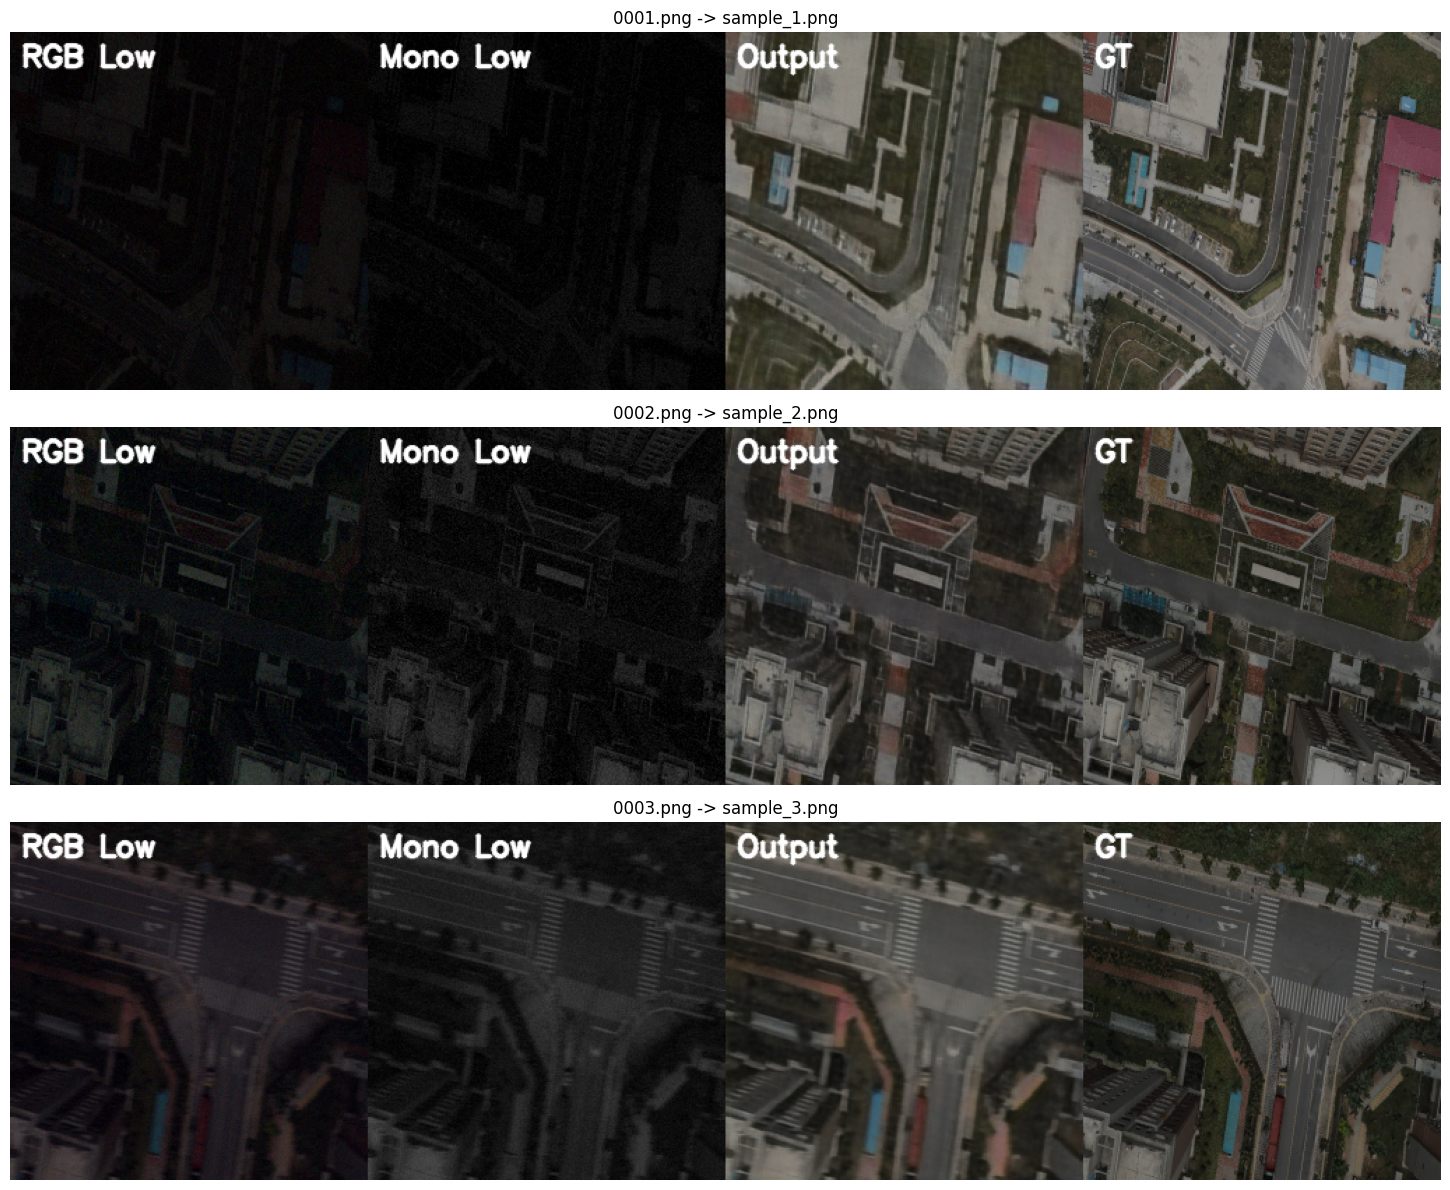

In [10]:
# 8. Visualization


def tensor_to_rgb_uint8(image: torch.Tensor) -> np.ndarray:
    image = image.detach().cpu().float().clamp(0.0, 1.0)
    if image.dim() == 3 and image.size(0) == 1:
        image = image.repeat(3, 1, 1)
    array = image.permute(1, 2, 0).numpy()
    return (array * 255.0).round().astype(np.uint8)


def tensor_to_mono_uint8(image: torch.Tensor) -> np.ndarray:
    image = image.detach().cpu().float().clamp(0.0, 1.0)
    if image.dim() == 3:
        image = image.squeeze(0)
    return (image.numpy() * 255.0).round().astype(np.uint8)


def annotate_panel(image_rgb: np.ndarray, label: str) -> np.ndarray:
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cv2.putText(image_bgr, label, (8, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def save_comparison_image(sample: dict, save_path: Path) -> np.ndarray:
    rgb_low = tensor_to_rgb_uint8(sample["rgb_low"])
    mono_low = tensor_to_mono_uint8(sample["mono_low"])
    mono_low_rgb = cv2.cvtColor(mono_low, cv2.COLOR_GRAY2RGB)
    output = tensor_to_rgb_uint8(sample["output"])
    gt = tensor_to_rgb_uint8(sample["gt"])

    comparison = np.concatenate(
        [
            annotate_panel(rgb_low, "RGB Low"),
            annotate_panel(mono_low_rgb, "Mono Low"),
            annotate_panel(output, "Output"),
            annotate_panel(gt, "GT"),
        ],
        axis=1,
    )
    cv2.imwrite(str(save_path), cv2.cvtColor(comparison, cv2.COLOR_RGB2BGR))
    return comparison


if not visual_samples:
    raise RuntimeError("No visual samples were collected during evaluation.")

for existing_file in OUTPUT_DIR.glob("sample_*.png"):
    existing_file.unlink()

saved_panels = []
for index, sample in enumerate(visual_samples, start=1):
    save_path = OUTPUT_DIR / f"sample_{index}.png"
    panel = save_comparison_image(sample, save_path)
    saved_panels.append((sample, panel, save_path))

print(f"Saved {len(saved_panels)} comparison images to {OUTPUT_DIR}")

display_panels = saved_panels[: min(NUM_RESULTS_TO_DISPLAY, len(saved_panels))]
fig, axes = plt.subplots(len(display_panels), 1, figsize=(18, 4 * len(display_panels)))
if len(display_panels) == 1:
    axes = [axes]

for axis, (sample, panel, save_path) in zip(axes, display_panels):
    axis.imshow(panel)
    axis.set_title(f"{sample['name']} -> {save_path.name}")
    axis.axis("off")
    print(f"Displayed and saved: {save_path}")

plt.tight_layout()
plt.show()


## Notes

**What TELU changes in training behavior**

TELU is smoother than hard-threshold ReLU behavior, so it can preserve weak responses from dark regions instead of zeroing them abruptly. In low-light enhancement, those weak activations can contain fine edges and subtle textures.

**Why synthetic data may limit performance**

Synthetic low-light data is useful for pipeline development, but it does not perfectly model real camera noise, motion blur, cross-sensor misalignment, exposure instability, or aerial-scene lighting changes. Because of that, strong synthetic results do not always translate directly to real-world performance.

**How to improve results**

- train for more epochs
- increase dataset size
- compare `use_telu=True` and `use_telu=False`
- tune the L1 and edge-loss weights
- add perceptual or frequency losses
- fine-tune on real RGB-mono low-light pairs when available
